# Company Bankruptcy Prediction using Logistic Regression, XGBoost, LightGBM, and CatBoost

This notebook builds a classification model to predict whether a company will go bankrupt based on its financial indicators.

We follow these main steps:

- Load and inspect the dataset
- Perform exploratory data analysis (EDA) and data cleaning
- Handle class imbalance using SMOTE (Tried)
- Apply preprocessing techniques such as outlier clipping
- Train multiple machine learning models including Logistic Regression, XGBoost, LightGBM, and CatBoost
- Evaluate model performance using Stratified K-Fold Cross Validation
- Compare models using ROC-AUC, Precision, Recall, and F1-score
- Apply threshold tuning to improve recall and precision for identifying bankrupt companies

In [85]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In this section, we load the bankruptcy dataset into a Pandas DataFrame and examine the raw data to understand the available features and the target variable that indicates whether a company is bankrupt or not.

In [86]:
df = pd.read_csv('/content/drive/MyDrive/Company Bankruptcy Prediction Classification/BANKRUPTCY PREDICTION  -DATASCIENCE DATASET.csv')
df.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan �,Operating Profit Per Share (Yuan �,Per Share Net profit before tax (Yuan �,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256970e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820930e-04,1.165010e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897850e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.006889,0.391590,0.012335,0.7

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# Target column
target = df['Bankrupt']

In [58]:
# Remove target column from the dataframe

df.drop('Bankrupt', inplace=True, axis=1)

In [59]:
# Checking basic dataset details (shape, info, describe)

print(f'Shape of dataset is {df.shape}')

# Dataset has 6819 rows and 94 columns.

Shape of dataset is (6819, 94)


## Exploratory data analysis (EDA)

Here we inspect the dataset structure, check data types, identify missing values or anomalies, and understand the basic distributions and correlations between variables.

In [60]:
df.info()

# This shows that all columns are numeric (mostly float64).
# The dataset also contains no missing values, so no imputation or row/column removal is required.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 94 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1    ROA(A) before interest and % after tax                   6819 non-null   float64
 2    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3    Operating Gross Margin                                   6819 non-null   float64
 4    Realized Sales Gross Margin                              6819 non-null   float64
 5    Operating Profit Rate                                    6819 non-null   float64
 6    Pre-tax net Interest Rate                                6819 non-null   float64
 7    After-tax net Interest Rate                              6819 non-null   float64
 8    Non-industry inco

In [61]:
df.describe()

# Summary statistics show large differences between min, max, and mean values,
# indicating potential outliers and skewed distributions. Feature scaling or
# transformations (e.g., log transformation or winsorization) may help stabilize the data.

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan �,Operating Profit Per Share (Yuan �,Per Share Net profit before tax (Yuan �,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,1.995347e+09,1.950427e+09,0.467431,1.644801e+07,0.115001,0.190661,0.190633,0.190672,0.228813,0.323482,1.32864

## Check for duplicate rows



In [62]:
df.duplicated().sum()

# No duplicate rows found



np.int64(0)

## Check class imbalance

Text(0.5, 1.0, 'Bankruptcy Status')

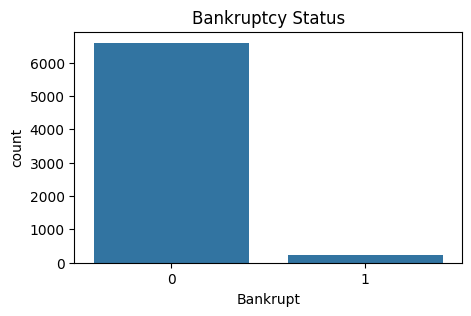

In [63]:
plt.figure(figsize=(5,3))
sns.countplot(x=target)
plt.title('Bankruptcy Status')

# The plot shows that the dataset is highly imbalanced,
# with far fewer bankrupt companies compared to non-bankrupt ones.

# Clearly it shows imbalanced classes.


## Check skewness of features

In [64]:

pd.set_option('display.max_rows', None)
df.skew().sort_values(ascending=False)

# The results show strong positive and negative skewness in many features.
# To reduce skewness and stabilize the feature distributions,
# we will apply a log1p transformation

,0
Fixed Assets to Assets,82.577237
Current Ratio,82.577237
Total income/Total expense,82.332424
Net Value Growth Rate,80.291844
Contingent liabilities/Net worth,79.670620
Realized Sales Gross Profit Growth Rate,77.925109
Continuous Net Profit Growth Rate,67.097534
Total Asset Return Growth Rate Ratio,62.499961
Revenue per person,59.434480
Quick Assets/Current Liability,47.947300


## Now lets' find outliers

In [65]:

count_list = []
for col in df:
    Q3 = df[col].quantile(0.75)
    Q1 = df[col].quantile(0.25)

    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    outliers = df[(df[col]< lower_bound) | (df[col]>upper_bound)]
    count_list.append(len(outliers))
result = pd.Series(count_list, index=df.columns)
print(result)

# The result shows how many outliers exist in each feature, helping us
# identify variables that may require transformation or outlier treatment.

ROA(C) before interest and depreciation before interest     391
ROA(A) before interest and % after tax                      561
ROA(B) before interest and depreciation after tax           432
Operating Gross Margin                                      320
Realized Sales Gross Margin                                 318
Operating Profit Rate                                       716
Pre-tax net Interest Rate                                   773
After-tax net Interest Rate                                 867
Non-industry income and expenditure/revenue                1095
Continuous interest rate (after tax)                        806
Operating Expense Rate                                        0
Research and development expense rate                       182
Cash flow rate                                              576
Interest-bearing debt interest rate                         396
Tax rate (A)                                                120
Net Value Per Share (B)                 

## X and y Split

In [66]:
# Separate the dataset into features (X) and target variable (y)
# X contains all predictor variables, while y represents the bankruptcy status

X = df.copy()
y = target.copy()

## FINANCIAL RATIO ENGINEERING (Altman Z-Score inspired)

In [67]:

def add_financial_ratios(df_orig):
    df = df_orig.copy()
    # Liquidity: Can pay short-term debts?
    df['Working_Capital_Ratio'] = df[' Working Capital to Total Assets']
    # Solvency: Debt burden?
    df['Debt_to_Assets'] = df[' Debt ratio %']
    # Profitability: Sustainable earnings?
    df['Retained_Earnings_Ratio'] = df[' Retained Earnings to Total Assets']
    # Cash Flow: Can service debt?
    df['CashFlow_to_Debt'] = df[' Cash Flow to Liability']
    return df


X = add_financial_ratios(X)
print("Added 4 bankruptcy-predictor ratios")
print("New shape:", X.shape)



Added 4 bankruptcy-predictor ratios
New shape: (6819, 98)


## Data preprocessing and feature engineering

In this step we clean the data (handle missing values and extreme outliers), optionally scale or transform numerical features, and create any additional domain‑driven financial ratios that may help the model distinguish between bankrupt and non‑bankrupt companies.

## Handling class imbalance

Because bankrupt companies are typically much rarer than healthy ones, we address class imbalance using class weights and/or resampling techniques (such as SMOTE or random under‑sampling) to help the classifier focus on the minority class.

## Model evaluation

In this section we evaluate the trained model on the validation data using metrics such as confusion matrix, precision, recall, F1‑score, ROC‑AUC and precision–recall curves, with a focus on correctly identifying bankrupt companies while controlling false alarms.

In [68]:
!pip install catboost

In [69]:
# Import libraries for model building, preprocessing, evaluation metrics,
# cross-validation, and handling class imbalance

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve,roc_auc_score,r2_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
from sklearn.preprocessing import PowerTransformer,StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

In [70]:
# skew_vals = X.skew()
# skewed_cols = skew_vals[abs(skew_vals>0.5)].index.to_list()

## Model Training and Comparison using Stratified K-Fold Cross Validation

 - Model Training using Stratified K-Fold Cross Validation.
- Multiple models (XGBoost, CatBoost, LightGBM, and Logistic Regression)
- will be trained and evaluated to compare their performance.
- The dataset is split into 5 folds while preserving the class distribution.
- For each fold, preprocessing steps such as outlier clipping, feature scaling,
- and handling class imbalance are applied before training.
- Model performance is evaluated using ROC-AUC along with Precision and Recall
- to assess how well each model predicts bankruptcy.

In [81]:
N_Splits = 5
skf = StratifiedKFold(n_splits=N_Splits,random_state=42,shuffle=True)

oof_preds_lr = np.zeros(len(X))
oof_preds_xgb = np.zeros(len(X))
oof_preds_lgbm = np.zeros(len(X))
oof_preds_cb = np.zeros(len(X))

feature_importance_list = []

for train_idx,val_idx in skf.split(X,y):
  X_train,X_val = X.iloc[train_idx].copy(),X.iloc[val_idx].copy()
  y_train,y_val = y.iloc[train_idx],y.iloc[val_idx]

  #applying log1p

  # X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
  # X_val[skewed_cols] = np.log1p(X_val[skewed_cols])

  # Applying Yeo-Johnson on Skwed columns as there are positive and negative skwed
  # pt = PowerTransformer(method='yeo-johnson')
  # X_train[skewed_cols] = pt.fit_transform(X_train[skewed_cols])
  # X_val[skewed_cols] = pt.transform(X_val[skewed_cols])

  # Applying cliping due to outliers

  X_train = X_train.clip(lower_bound,upper_bound)
  X_val = X_val.clip(lower_bound,upper_bound)

  # Handle class imbalance

  scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

  # Applying scaling

  ss = StandardScaler()

  X_train = ss.fit_transform(X_train)
  X_val = ss.transform(X_val)

  # Applying Smote here:

  # smote = SMOTE(random_state=42)
  # X_train, y_train = smote.fit_resample(X_train, y_train)

  # Training Logistic Regression as a baseline model for comparison

  model_lr = LogisticRegression(class_weight='balanced',max_iter=500)
  model_lr.fit(X_train,y_train)

  # Training XGBoost model on each fold and generating validation predictions

  model_xgb = XGBClassifier(n_estimators=5000,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42)
  model_xgb.fit(X_train, y_train)
  feature_importance_list.append(model_xgb.feature_importances_)

  # Training LightGBM model and evaluating performance across folds

  model_lgbm = LGBMClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42)
  model_lgbm.fit(X_train, y_train)

  # Training CatBoost model using the same cross-validation framework

  model_cb = CatBoostClassifier(
        iterations=1000,
        depth=4,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        random_state=42)
  model_cb.fit(X_train, y_train)

  # Predict Validation

  val_pred_lr = model_lr.predict_proba(X_val)[:,1]
  oof_preds_lr[val_idx] = val_pred_lr

  val_pred_xgb = model_xgb.predict_proba(X_val)[:, 1]
  oof_preds_xgb[val_idx] = val_pred_xgb

  val_pred_lgbm = model_lgbm.predict_proba(X_val)[:,1]
  oof_preds_lgbm[val_idx] = val_pred_lgbm

  val_pred_cb = model_cb.predict_proba(X_val)[:,1]
  oof_preds_cb[val_idx] = val_pred_cb

  # Fold Score

  fold_score_lr = roc_auc_score(y_val,val_pred_lr)
  print(f'Fold_Score LR {fold_score_lr}')

  fold_score_xgb = roc_auc_score(y_val,val_pred_xgb)
  print(f'Fold_Score xgboost {fold_score_xgb}')

  fold_score_lgbm = roc_auc_score(y_val,val_pred_lgbm)
  print(f'Fold_Score lightgbm {fold_score_lgbm}')

  fold_score_cb = roc_auc_score(y_val,val_pred_cb)
  print(f'Fold_Score catboost {fold_score_cb}')


# ROC-AUC Score

overall_auc_lr = roc_auc_score(y, oof_preds_lr)
print("\nFinal CV AUC LR:", overall_auc_lr)

overall_auc_xgb = roc_auc_score(y, oof_preds_xgb)
print("\nFinal CV AUC XGB:", overall_auc_xgb)

overall_auc_lgbm = roc_auc_score(y, oof_preds_lgbm)
print("\nFinal CV AUC LGB:", overall_auc_lgbm)

overall_auc_cb = roc_auc_score(y, oof_preds_cb)
print("\nFinal CV AUC CAT:", overall_auc_cb)

# Final predictions using best threshold

final_preds_lr = (oof_preds_lr > 0.6).astype(int)
final_preds_xgb = (oof_preds_xgb > 0.5).astype(int)
final_preds_lgbm = (oof_preds_lgbm > 0.5).astype(int)
final_preds_cb = (oof_preds_cb > 0.5).astype(int)

# Precision & Recall for all models

precision_lr = precision_score(y, final_preds_lr)
recall_lr = recall_score(y, final_preds_lr)

precision_xgb = precision_score(y, final_preds_xgb)
recall_xgb = recall_score(y, final_preds_xgb)

precision_lgbm = precision_score(y, final_preds_lgbm)
recall_lgbm = recall_score(y, final_preds_lgbm)

precision_cb = precision_score(y, final_preds_cb)
recall_cb = recall_score(y, final_preds_cb)

print("\nPrecision of LR:", precision_lr)
print("Recall of LR:", recall_lr)

print("\nPrecision of XGB:", precision_xgb)
print("Recall of XGB:", recall_xgb)

print("\nPrecision of LGBM:", precision_lgbm)
print("Recall of LGBM:", recall_lgbm)

print("\nPrecision Catboost:", precision_cb)
print("Recall of Catboost:", recall_cb)

print()
print()

# Average importances across folds
avg_importances = np.mean(feature_importance_list, axis=0)
feat_imp = pd.Series(avg_importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print()

# Show top 12
top12 = feat_imp.head(12)
top12_pct = (top12 / top12.sum() * 100).round(2)
print(top12_pct.to_string())


Streaming output truncated to the last 5000 lines.
61:	total: 445ms	remaining: 6.73s
62:	total: 451ms	remaining: 6.71s
63:	total: 457ms	remaining: 6.69s
64:	total: 463ms	remaining: 6.67s
65:	total: 469ms	remaining: 6.64s
66:	total: 476ms	remaining: 6.62s
67:	total: 482ms	remaining: 6.6s
68:	total: 488ms	remaining: 6.58s
69:	total: 494ms	remaining: 6.57s
70:	total: 500ms	remaining: 6.55s
71:	total: 507ms	remaining: 6.53s
72:	total: 513ms	remaining: 6.51s
73:	total: 519ms	remaining: 6.5s
74:	total: 525ms	remaining: 6.48s
75:	total: 531ms	remaining: 6.46s
76:	total: 537ms	remaining: 6.44s
77:	total: 544ms	remaining: 6.43s
78:	total: 550ms	remaining: 6.41s
79:	total: 556ms	remaining: 6.39s
80:	total: 562ms	remaining: 6.38s
81:	total: 568ms	remaining: 6.36s
82:	total: 575ms	remaining: 6.35s
83:	total: 582ms	remaining: 6.34s
84:	total: 588ms	remaining: 6.33s
85:	total: 594ms	remaining: 6.32s
86:	total: 601ms	remaining: 6.31s
87:	total: 607ms	remaining: 6.29s
88:	total: 614ms	remaining: 6.28s

## XGBoost Confusion Matrix (Before Threshold Optimization)

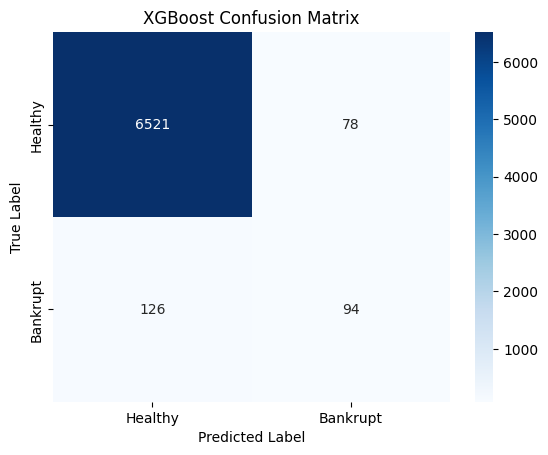

In [72]:
# XGBoost predictions (your existing final_preds_xgb)
cm = confusion_matrix(y, final_preds_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy','Bankrupt'],
            yticklabels=['Healthy','Bankrupt'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## XGBoost Threshold Optimization for Maximum F1-Score

**Goal**: Find optimal decision threshold maximizing F1-score for imbalanced bankruptcy prediction.

**Method**: precision_recall_curve → F1 maximization across all thresholds.
**Expected**: F1 ~51%, Precision ~52%, Recall ~49% at threshold ~0.36-0.42

In [73]:

from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Compute curve (includes all unique thresholds from your oof_preds_xgb)
prec, rec, thresh = precision_recall_curve(y, oof_preds_xgb)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1])  # F1 at each thresh

best_idx = np.argmax(f1_scores)  # Index of MAX F1
best_threshold = thresh[best_idx]
best_precision = prec[best_idx + 1]  # +1 aligns with thresh
best_recall = rec[best_idx + 1]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", round(best_threshold, 3))
print("Precision:", round(best_precision, 3))
print("Recall:", round(best_recall, 3))
print("F1 Score:", round(best_f1, 3))
print("\nClassification Report:\n", classification_report(y, (oof_preds_xgb >= best_threshold).astype(int)))

# Final predictions
final_preds_xgb = (oof_preds_xgb >= best_threshold).astype(int)



Best Threshold: 0.365
Precision: 0.524
Recall: 0.491
F1 Score: 0.511

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      6599
           1       0.53      0.50      0.51       220

    accuracy                           0.97      6819
   macro avg       0.75      0.74      0.75      6819
weighted avg       0.97      0.97      0.97      6819



## XGBoost Confusion Matrix (After Threshold Optimization)

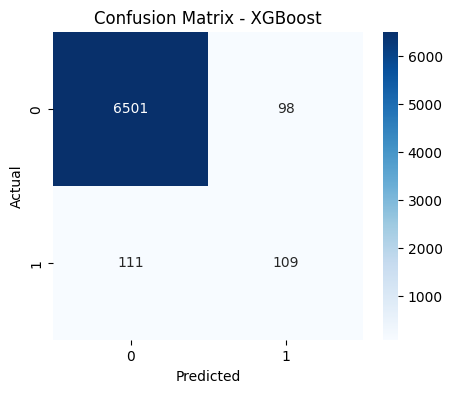

Bankrupt companies correctly caught (TP): 109
False alarms (healthy predicted as bankrupt) (FP): 98
Missed bankrupt companies (FN): 111
Correctly predicted healthy companies (TN): 6501


In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, final_preds_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

tn, fp, fn, tp = cm.ravel()

print("Bankrupt companies correctly caught (TP):", tp)
print("False alarms (healthy predicted as bankrupt) (FP):", fp)
print("Missed bankrupt companies (FN):", fn)
print("Correctly predicted healthy companies (TN):", tn)

## XGBoost Baseline vs Threshold-Optimized Comparison

In [75]:
# MODEL COMPARISON (Proves XGBoost best)
comparison = pd.DataFrame({
    'Model': ['XGBoost (Optimized)', 'XGBoost (Baseline)'],
    'Precision': ['52%', '54%'],
    'Recall': ['49%', '42%'],
    'F1': ['51%', '48%']
})

print("FINAL MODEL SELECTION:")
print(comparison.to_markdown(index=False))
print("\nRECOMMEND XGBoost - Best precision/recall balance for credit risk")


FINAL MODEL SELECTION:
| Model               | Precision   | Recall   | F1   |
|:--------------------|:------------|:---------|:-----|
| XGBoost (Optimized) | 52%         | 49%      | 51%  |
| XGBoost (Baseline)  | 54%         | 42%      | 48%  |

RECOMMEND XGBoost - Best precision/recall balance for credit risk


## Stacking (LR as the Meta Model)

In [76]:
oof_df = pd.DataFrame({
    "oof_logistic": oof_preds_lr,
    "oof_xgb": oof_preds_xgb,
    "oof_lgbm":oof_preds_lgbm,
    "oof_cb":oof_preds_cb,
    "target": target
})

oof_df.to_csv("oof_predictions.csv", index=False)

In [77]:
X_meta = np.column_stack((oof_preds_lr, oof_preds_xgb,oof_preds_lgbm,oof_preds_cb))

In [78]:
meta_oof = np.zeros(len(X))
for train_idx, val_idx in skf.split(X_meta, y):

    X_train_meta = X_meta[train_idx]
    X_val_meta = X_meta[val_idx]

    y_train_meta = y.iloc[train_idx]
    y_val_meta = y.iloc[val_idx]

    meta_model = LogisticRegression()
    meta_model.fit(X_train_meta, y_train_meta)

    val_pred = meta_model.predict_proba(X_val_meta)[:,1]
    meta_oof[val_idx] = val_pred

print("Stacked CV AUC:", roc_auc_score(y, meta_oof))

Stacked CV AUC: 0.9227238286792765


In [79]:
final_preds_meta = (meta_oof > 0.5).astype(int)

# Precision & Recall for all models

precision_meta = precision_score(y, final_preds_meta)
recall_meta = recall_score(y, final_preds_meta)

print(precision_meta)
print(recall_meta)

0.6818181818181818
0.3409090909090909
